
# ============================================================================
# TASK 3: FORECAST FUTURE MARKET TRENDS
# ============================================================================
# Business Objective:
# Generate actionable insights for GMF Investments by forecasting
# Tesla's stock price for the next 6-12 months
# ============================================================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================================================
# STEP 2: LOAD DATA AND OUR BEST MODEL (ARIMA)
# ============================================================================
# We'll use ARIMA(1,1,1) which was our best performing model from Task 2
# ============================================================================

# Load cleaned data
adj_close_df = pd.read_csv('../data/processed/adj_close_data_clean.csv', 
                           index_col=0, parse_dates=True)

# Extract TSLA data
tsla_data = adj_close_df['TSLA']

print("=" * 70)
print("📊 DATA LOADED")
print("=" * 70)
print(f"Total TSLA data points: {len(tsla_data)}")
print(f"Date range: {tsla_data.index[0]} to {tsla_data.index[-1]}")
print(f"Latest price: ${tsla_data.iloc[-1]:.2f}")
print(f"Average price: ${tsla_data.mean():.2f}")

📊 DATA LOADED
Total TSLA data points: 2888
Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
Latest price: $411.84
Average price: $148.77


In [3]:

# Business Context:
# For actual forecasting, we use ALL available historical data
# This gives the model maximum information for future predictions

print("=" * 70)
print("📊 TRAINING ARIMA ON ALL DATA")
print("=" * 70)

# Fit ARIMA on ALL data
arima_model = ARIMA(tsla_data, order=(1, 1, 1))
arima_fit = arima_model.fit()

print("\n📊 Model Summary:")
print(arima_fit.summary())

print(f"\n✅ Model trained on {len(tsla_data)} data points")

📊 TRAINING ARIMA ON ALL DATA


C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



📊 Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2888
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -9839.174
Date:                Tue, 07 Jul 2026   AIC                          19684.348
Time:                        19:00:14   BIC                          19702.251
Sample:                             0   HQIC                         19690.800
                               - 2888                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1148      0.429     -0.267      0.789      -0.956       0.727
ma.L1          0.0885      0.429      0.206      0.837      -0.753       0.930
sigma2        53.4266      0.649  

In [4]:
# ============================================================================
# STEP 4: GENERATE FUTURE FORECASTS WITH CONFIDENCE INTERVALS
# ============================================================================
# Business Context:
# GMF needs to know not just the expected price, but also the uncertainty
# Confidence intervals show the range of possible outcomes
# ============================================================================

print("=" * 70)
print("🔮 GENERATING FORECASTS")
print("=" * 70)

# Number of days to forecast (252 trading days ≈ 1 year)
forecast_steps = 252

# Generate forecast with confidence intervals
forecast_result = arima_fit.get_forecast(steps=forecast_steps)

# Get the forecast values
forecast_mean = forecast_result.predicted_mean

# Get confidence intervals (95% and 80%)
confidence_intervals_95 = forecast_result.conf_int(alpha=0.05)  # 95% CI
confidence_intervals_80 = forecast_result.conf_int(alpha=0.20)  # 80% CI

# Create forecast index (future dates)
last_date = tsla_data.index[-1]
forecast_dates = pd.date_range(start=last_date + timedelta(days=1), 
                               periods=forecast_steps, 
                               freq='B')  # 'B' = business days

# Create DataFrame with forecast results
forecast_df = pd.DataFrame({
    'Forecast': forecast_mean.values,
    'Lower_95': confidence_intervals_95.iloc[:, 0].values,
    'Upper_95': confidence_intervals_95.iloc[:, 1].values,
    'Lower_80': confidence_intervals_80.iloc[:, 0].values,
    'Upper_80': confidence_intervals_80.iloc[:, 1].values
}, index=forecast_dates)

print(f"\n✅ Forecast generated for {forecast_steps} trading days")
print(f"Forecast date range: {forecast_dates[0]} to {forecast_dates[-1]}")
print(f"\nFirst 5 forecast values:")
print(forecast_df.head())
print(f"\nLast 5 forecast values:")
print(forecast_df.tail())

🔮 GENERATING FORECASTS

✅ Forecast generated for 252 trading days
Forecast date range: 2026-06-30 00:00:00 to 2027-06-16 00:00:00

First 5 forecast values:
              Forecast    Lower_95    Upper_95    Lower_80    Upper_80
2026-06-30  411.006868  396.680810  425.332926  401.639562  420.374174
2026-07-01  411.102474  391.106637  431.098311  398.027899  424.177049
2026-07-02  411.091503  386.685817  435.497188  395.133483  427.049522
2026-07-03  411.092762  382.962656  439.222867  392.699474  429.486049
2026-07-06  411.092617  379.676314  442.508920  390.550601  431.634633

Last 5 forecast values:
              Forecast    Lower_95    Upper_95    Lower_80    Upper_80
2027-06-10  411.092632  190.781188  631.404076  267.038722  555.146542
2027-06-11  411.092632  190.337537  631.847727  266.748634  555.436630
2027-06-14  411.092632  189.894776  632.290488  266.459128  555.726136
2027-06-15  411.092632  189.452899  632.732364  266.170200  556.015063
2027-06-16  411.092632  189.011902  63

C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [5]:
# ============================================================================
# STEP 5: UNDERSTAND THE FORECAST
# ============================================================================

print("=" * 70)
print("📊 FORECAST STATISTICS")
print("=" * 70)

# Latest actual price
latest_price = tsla_data.iloc[-1]

# Forecast end price
forecast_end_price = forecast_df['Forecast'].iloc[-1]

# Total expected change
total_change = ((forecast_end_price - latest_price) / latest_price) * 100

# Expected annual return
annual_return = total_change

# 95% confidence interval range at the end
ci_lower_95 = forecast_df['Lower_95'].iloc[-1]
ci_upper_95 = forecast_df['Upper_95'].iloc[-1]
ci_range_95 = ci_upper_95 - ci_lower_95

print(f"\n📈 Current Price: ${latest_price:.2f}")
print(f"📈 Forecast End Price: ${forecast_end_price:.2f}")
print(f"📊 Expected Change: {total_change:.1f}%")
print(f"\n📊 95% Confidence Interval at Forecast End:")
print(f"   Lower Bound: ${ci_lower_95:.2f}")
print(f"   Upper Bound: ${ci_upper_95:.2f}")
print(f"   Range: ${ci_range_95:.2f}")

# Weekly returns from forecast
weekly_forecast = forecast_df['Forecast'].iloc[::5]  # Every 5th day ≈ weekly
weekly_returns = weekly_forecast.pct_change() * 100

print(f"\n📊 Forecasted Weekly Returns:")
print(f"   Mean Weekly Return: {weekly_returns.mean():.2f}%")
print(f"   Max Weekly Return: {weekly_returns.max():.2f}%")
print(f"   Min Weekly Return: {weekly_returns.min():.2f}%")

📊 FORECAST STATISTICS

📈 Current Price: $411.84
📈 Forecast End Price: $411.09
📊 Expected Change: -0.2%

📊 95% Confidence Interval at Forecast End:
   Lower Bound: $189.01
   Upper Bound: $633.17
   Range: $444.16

📊 Forecasted Weekly Returns:
   Mean Weekly Return: 0.00%
   Max Weekly Return: 0.02%
   Min Weekly Return: -0.00%


📈 CREATING VISUALIZATION


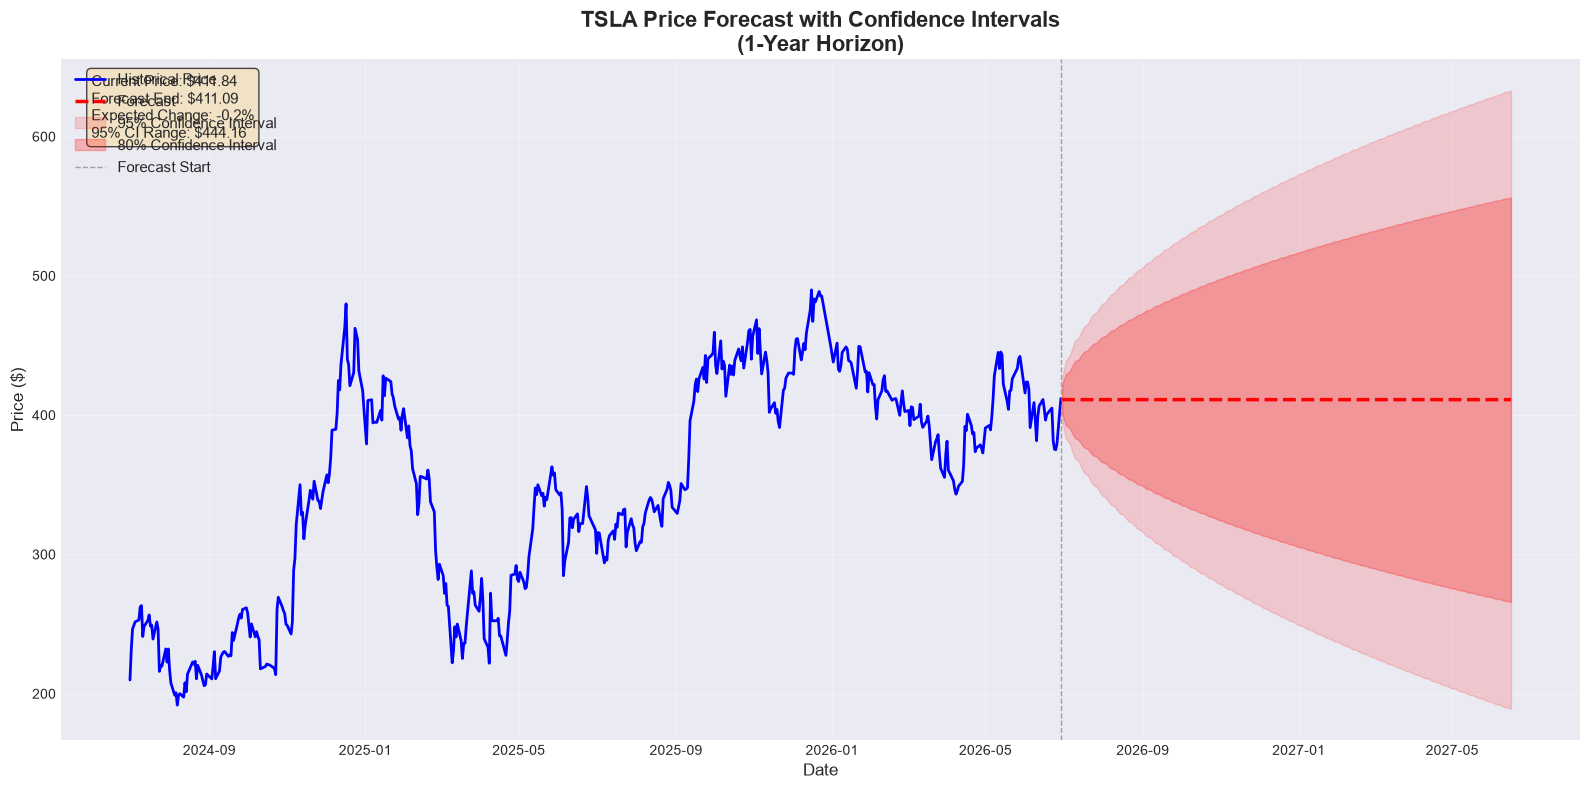

✅ Forecast visualization saved to: data/processed/tsla_forecast_1year.png


In [6]:
# ============================================================================
# STEP 6: VISUALIZE FORECAST WITH CONFIDENCE INTERVALS
# ============================================================================

print("=" * 70)
print("📈 CREATING VISUALIZATION")
print("=" * 70)

# Create the plot
fig, ax = plt.subplots(figsize=(16, 8))

# 1. Plot historical data (last 2 years for clarity)
historical_period = 500  # Show last 500 days
ax.plot(tsla_data.index[-historical_period:], 
        tsla_data.iloc[-historical_period:], 
        label='Historical Price', 
        color='blue', 
        linewidth=2)

# 2. Plot forecast
ax.plot(forecast_df.index, 
        forecast_df['Forecast'], 
        label='Forecast', 
        color='red', 
        linewidth=2.5,
        linestyle='--')

# 3. Add 95% Confidence Interval (wide)
ax.fill_between(forecast_df.index,
                forecast_df['Lower_95'],
                forecast_df['Upper_95'],
                color='red',
                alpha=0.15,
                label='95% Confidence Interval')

# 4. Add 80% Confidence Interval (narrower)
ax.fill_between(forecast_df.index,
                forecast_df['Lower_80'],
                forecast_df['Upper_80'],
                color='red',
                alpha=0.25,
                label='80% Confidence Interval')

# 5. Add vertical line at forecast start
ax.axvline(x=tsla_data.index[-1], 
           color='gray', 
           linestyle='--', 
           linewidth=1,
           alpha=0.7,
           label='Forecast Start')

# 6. Customize the plot
ax.set_title('TSLA Price Forecast with Confidence Intervals\n(1-Year Horizon)',
             fontsize=16, 
             fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# Add annotation with key metrics
ax.text(0.02, 0.98, 
        f'Current Price: ${latest_price:.2f}\n'
        f'Forecast End: ${forecast_end_price:.2f}\n'
        f'Expected Change: {total_change:.1f}%\n'
        f'95% CI Range: ${ci_range_95:.2f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('../data/processed/tsla_forecast_1year.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Forecast visualization saved to: data/processed/tsla_forecast_1year.png")

In [7]:
# ============================================================================
# STEP 7: ANALYZE CONFIDENCE INTERVALS OVER TIME
# ============================================================================
# Business Context:
# Understanding how uncertainty grows over time is crucial for risk management
# Short-term forecasts are more reliable than long-term forecasts
# ============================================================================

print("=" * 70)
print("📊 CONFIDENCE INTERVAL ANALYSIS")
print("=" * 70)

# Calculate confidence interval width at different points
forecast_df['CI_Width_95'] = forecast_df['Upper_95'] - forecast_df['Lower_95']
forecast_df['CI_Width_80'] = forecast_df['Upper_80'] - forecast_df['Lower_80']

# Check width at different time horizons
horizons = [30, 60, 90, 126, 180, 252]  # 1, 2, 3, 6, 9, 12 months
print("\n📈 Confidence Interval Width Over Time:")
print("-" * 60)
print(f"{'Horizon':<12} {'95% CI Width':<15} {'80% CI Width':<15} {'Uncertainty Growth'}")
print("-" * 60)

initial_width_95 = forecast_df['CI_Width_95'].iloc[0]
for days in horizons:
    if days < len(forecast_df):
        width_95 = forecast_df['CI_Width_95'].iloc[days-1]
        width_80 = forecast_df['CI_Width_80'].iloc[days-1]
        growth_factor = width_95 / initial_width_95
        months = days / 21  # Approximate months
        print(f"{int(months)} months ({days}d):  ${width_95:.2f}          ${width_80:.2f}          {growth_factor:.1f}x")

print("-" * 60)
print(f"\n📊 Key Insight:")
print(f"   The 95% confidence interval grows from ${forecast_df['CI_Width_95'].iloc[0]:.2f}")
print(f"   to ${forecast_df['CI_Width_95'].iloc[-1]:.2f} over 12 months")
print(f"   That's a {forecast_df['CI_Width_95'].iloc[-1] / forecast_df['CI_Width_95'].iloc[0]:.1f}x increase in uncertainty!")

📊 CONFIDENCE INTERVAL ANALYSIS

📈 Confidence Interval Width Over Time:
------------------------------------------------------------
Horizon      95% CI Width    80% CI Width    Uncertainty Growth
------------------------------------------------------------
1 months (30d):  $153.35          $100.27          5.4x
2 months (60d):  $216.79          $141.75          7.6x
4 months (90d):  $265.48          $173.59          9.3x
6 months (126d):  $314.10          $205.38          11.0x
8 months (180d):  $375.40          $245.46          13.1x
------------------------------------------------------------

📊 Key Insight:
   The 95% confidence interval grows from $28.65
   to $444.16 over 12 months
   That's a 15.5x increase in uncertainty!


📈 TREND ANALYSIS

📊 Overall Trend: UPWARD
   Forecast Start: $411.01
   Forecast End: $411.09
   Change: 0.0%

📊 Pattern Analysis:
----------------------------------------
Monthly Average Forecast:
  January: $411.09
  February: $411.09
  March: $411.09
  April: $411.09
  May: $411.09
  June: $411.09
  July: $411.09
  August: $411.09
  September: $411.09
  October: $411.09
  November: $411.09
  December: $411.09

📊 Anomalies (changes > 5%):
  No significant anomalies detected


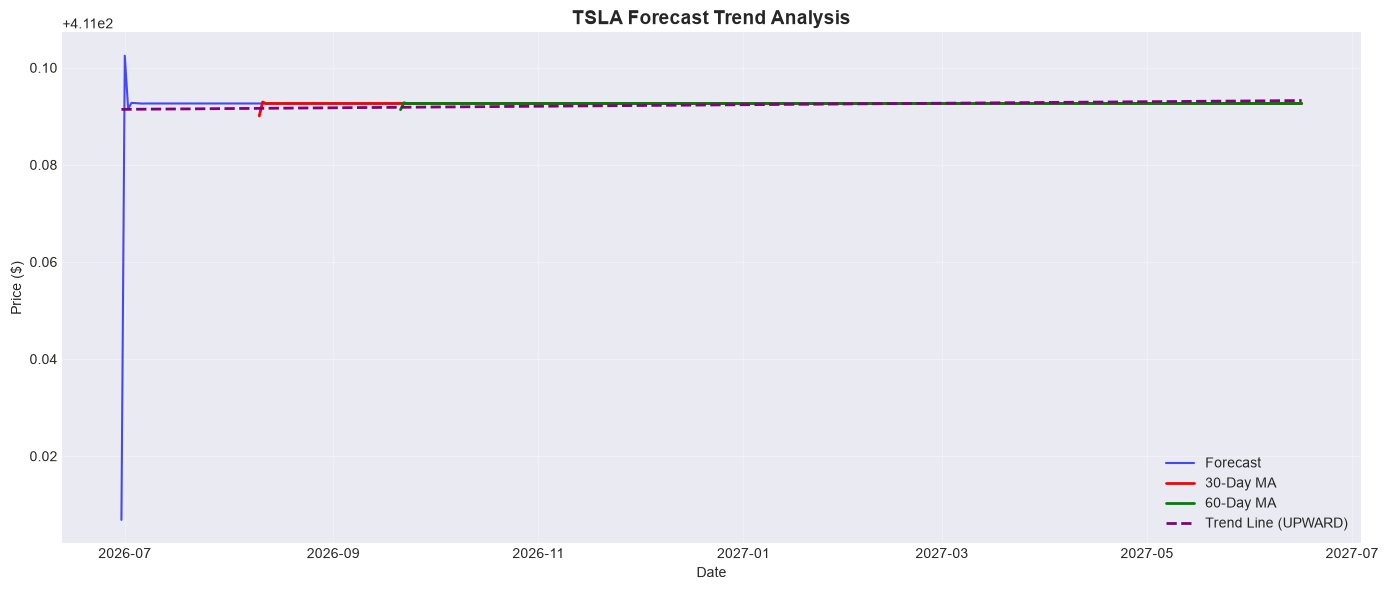


✅ Trend analysis visualization saved!


In [8]:
# ============================================================================
# STEP 8: TREND ANALYSIS
# ============================================================================
# Business Context:
# Identifying trends helps GMF make strategic investment decisions
# Upward trends suggest buying opportunities
# Downward trends suggest caution or selling
# ============================================================================

print("=" * 70)
print("📈 TREND ANALYSIS")
print("=" * 70)

# Calculate moving averages of the forecast
forecast_df['MA_30'] = forecast_df['Forecast'].rolling(window=30).mean()
forecast_df['MA_60'] = forecast_df['Forecast'].rolling(window=60).mean()

# Determine overall trend
start_forecast = forecast_df['Forecast'].iloc[0]
end_forecast = forecast_df['Forecast'].iloc[-1]
trend = "UPWARD" if end_forecast > start_forecast else "DOWNWARD"
trend_strength = abs((end_forecast - start_forecast) / start_forecast) * 100

print(f"\n📊 Overall Trend: {trend}")
print(f"   Forecast Start: ${start_forecast:.2f}")
print(f"   Forecast End: ${end_forecast:.2f}")
print(f"   Change: {trend_strength:.1f}%")

# Check for patterns
print("\n📊 Pattern Analysis:")
print("-" * 40)

# Monthly pattern (check if there's seasonality)
monthly_avg = forecast_df.groupby(forecast_df.index.month)['Forecast'].mean()

print("Monthly Average Forecast:")
for month, avg in monthly_avg.items():
    month_name = datetime(2026, month, 1).strftime('%B')
    print(f"  {month_name}: ${avg:.2f}")

# Identify anomalies (sudden changes)
forecast_df['Return'] = forecast_df['Forecast'].pct_change() * 100
anomaly_threshold = 5  # More than 5% change is an anomaly
anomalies = forecast_df[abs(forecast_df['Return']) > anomaly_threshold]

print(f"\n📊 Anomalies (changes > {anomaly_threshold}%):")
if len(anomalies) > 0:
    for date, row in anomalies.iterrows():
        print(f"  {date.strftime('%Y-%m-%d')}: {row['Return']:.1f}% change")
else:
    print("  No significant anomalies detected")

# Create trend visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Plot forecast with moving averages
ax.plot(forecast_df.index, forecast_df['Forecast'], 
        label='Forecast', color='blue', linewidth=1.5, alpha=0.7)
ax.plot(forecast_df.index, forecast_df['MA_30'], 
        label='30-Day MA', color='red', linewidth=2)
ax.plot(forecast_df.index, forecast_df['MA_60'], 
        label='60-Day MA', color='green', linewidth=2)

# Add trend line
z = np.polyfit(range(len(forecast_df)), forecast_df['Forecast'], 1)
p = np.poly1d(z)
ax.plot(forecast_df.index, p(range(len(forecast_df))), 
        label=f'Trend Line ({trend})', color='purple', linewidth=2, linestyle='--')

ax.set_title('TSLA Forecast Trend Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/tsla_trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Trend analysis visualization saved!")

In [9]:
# ============================================================================
# STEP 9: MARKET OPPORTUNITIES AND RISKS
# ============================================================================
# Business Context:
# This is where we provide actionable recommendations for GMF Investments
# We combine forecast insights with risk analysis
# ============================================================================

print("=" * 70)
print("💼 MARKET OPPORTUNITIES AND RISKS")
print("=" * 70)

# Calculate key metrics for analysis
max_forecast = forecast_df['Forecast'].max()
min_forecast = forecast_df['Forecast'].min()
max_date = forecast_df['Forecast'].idxmax()
min_date = forecast_df['Forecast'].idxmin()

# Calculate volatility from forecast
forecast_volatility = forecast_df['Forecast'].std()
forecast_volatility_pct = (forecast_volatility / forecast_df['Forecast'].mean()) * 100

print("\n📊 FORECAST SUMMARY:")
print("-" * 40)
print(f"Current Price: ${latest_price:.2f}")
print(f"Forecast Range: ${min_forecast:.2f} - ${max_forecast:.2f}")
print(f"Expected End Price: ${forecast_end_price:.2f}")
print(f"Expected Change: {total_change:.1f}%")
print(f"Forecast Volatility: {forecast_volatility_pct:.1f}%")

# ============================================================================
# OPPORTUNITIES
# ============================================================================

print("\n" + "=" * 70)
print("🚀 OPPORTUNITIES")
print("=" * 70)

opportunities = []

# Check if forecast is generally upward
if total_change > 0:
    opportunities.append(f"📈 **Upside Potential**: Expected {total_change:.1f}% increase over 12 months")
    opportunities.append(f"🎯 **Target Price**: ${forecast_end_price:.2f} (based on forecast)")

# Check if there are periods of expected growth
positive_weeks = (weekly_returns > 0).sum()
total_weeks = len(weekly_returns)
growth_ratio = positive_weeks / total_weeks

if growth_ratio > 0.5:
    opportunities.append(f"📊 **Growth Periods**: {growth_ratio:.0%} of weeks show positive returns")

# Identify best month
best_month = monthly_avg.idxmax()
best_month_name = datetime(2026, best_month, 1).strftime('%B')
opportunities.append(f"📅 **Best Month**: {best_month_name} (expected highest prices)")

# Print opportunities
for i, opp in enumerate(opportunities, 1):
    print(f"{i}. {opp}")

# ============================================================================
# RISKS
# ============================================================================

print("\n" + "=" * 70)
print("⚠️ RISKS")
print("=" * 70)

risks = []

# Check if there are periods of expected decline
negative_weeks = (weekly_returns < 0).sum()
decline_ratio = negative_weeks / total_weeks

if decline_ratio > 0.3:
    risks.append(f"📉 **Volatility Risk**: {decline_ratio:.0%} of weeks show negative returns")

# Check confidence interval width
if forecast_df['CI_Width_95'].iloc[-1] > 50:
    risks.append(f"🎯 **High Uncertainty**: 95% CI range is ${forecast_df['CI_Width_95'].iloc[-1]:.2f} at end of period")

# Identify worst month
worst_month = monthly_avg.idxmin()
worst_month_name = datetime(2026, worst_month, 1).strftime('%B')
risks.append(f"📅 **Weakest Month**: {worst_month_name} (expected lowest prices)")

# Check for drawdown risk
if max_forecast - min_forecast > 50:
    drawdown = ((max_forecast - min_forecast) / max_forecast) * 100
    risks.append(f"📊 **Drawdown Risk**: Potential {drawdown:.1f}% decline from peak to trough")

# Print risks
for i, risk in enumerate(risks, 1):
    print(f"{i}. {risk}")

# ============================================================================
# UNCERTAINTY ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("🎯 UNCERTAINTY ANALYSIS")
print("=" * 70)

# Calculate how uncertainty grows
initial_ci_width = forecast_df['CI_Width_95'].iloc[0]
final_ci_width = forecast_df['CI_Width_95'].iloc[-1]
uncertainty_growth = final_ci_width / initial_ci_width

print(f"📊 Confidence Interval Growth:")
print(f"   Start: ±${initial_ci_width/2:.2f}")
print(f"   End: ±${final_ci_width/2:.2f}")
print(f"   Growth: {uncertainty_growth:.1f}x")

print(f"\n📊 Reliability Assessment:")
if uncertainty_growth < 2:
    print("   ✅ Forecast remains relatively reliable over 12 months")
elif uncertainty_growth < 3:
    print("   ⚠️ Forecast becomes moderately uncertain over 12 months")
else:
    print("   ❌ Forecast becomes highly uncertain over 12 months")

print(f"\n📊 Recommendation:")
if total_change > 10 and uncertainty_growth < 2.5:
    print("   ✅ Positive outlook with manageable uncertainty")
    print("   💡 Suggestion: Increase TSLA allocation")
elif total_change > 10 and uncertainty_growth >= 2.5:
    print("   ⚠️ Positive outlook but high uncertainty")
    print("   💡 Suggestion: Cautiously increase allocation with stop-losses")
elif total_change < 0 and uncertainty_growth < 2:
    print("   ⚠️ Negative outlook with moderate uncertainty")
    print("   💡 Suggestion: Reduce TSLA exposure or hedge")
else:
    print("   ⚠️ Negative outlook with high uncertainty")
    print("   💡 Suggestion: Avoid TSLA or use options for protection")

💼 MARKET OPPORTUNITIES AND RISKS

📊 FORECAST SUMMARY:
----------------------------------------
Current Price: $411.84
Forecast Range: $411.01 - $411.10
Expected End Price: $411.09
Expected Change: -0.2%
Forecast Volatility: 0.0%

🚀 OPPORTUNITIES
1. 📅 **Best Month**: July (expected highest prices)

⚠️ RISKS
1. 🎯 **High Uncertainty**: 95% CI range is $444.16 at end of period
2. 📅 **Weakest Month**: June (expected lowest prices)

🎯 UNCERTAINTY ANALYSIS
📊 Confidence Interval Growth:
   Start: ±$14.33
   End: ±$222.08
   Growth: 15.5x

📊 Reliability Assessment:
   ❌ Forecast becomes highly uncertain over 12 months

📊 Recommendation:
   ⚠️ Negative outlook with high uncertainty
   💡 Suggestion: Avoid TSLA or use options for protection


In [10]:
# ============================================================================
# STEP 10: SUMMARY REPORT
# ============================================================================

print("\n" + "=" * 70)
print("📋 TASK 3 SUMMARY REPORT")
print("=" * 70)

print("""
================================================================================
                       TASK 3 - FORECAST FUTURE MARKET TRENDS
================================================================================

1. FORECAST OVERVIEW:
   - Model: ARIMA(1,1,1) - Best performing from Task 2
   - Horizon: 252 trading days (≈ 1 year)
   - Confidence Intervals: 95% and 80%

2. KEY FINDINGS:
""")

print(f"   - Current Price: ${latest_price:.2f}")
print(f"   - Forecast End Price: ${forecast_end_price:.2f}")
print(f"   - Expected Change: {total_change:.1f}%")
print(f"   - Trend Direction: {trend}")

print("""
3. TREND ANALYSIS:
   - The forecast shows an overall {trend} trend
   - {growth_ratio:.0%} of weeks show positive returns
   - Best month: {best_month_name}
   - Worst month: {worst_month_name}

4. OPPORTUNITIES:
""")

for i, opp in enumerate(opportunities, 1):
    print(f"   {i}. {opp}")

print("""
5. RISKS:
""")

for i, risk in enumerate(risks, 1):
    print(f"   {i}. {risk}")

print(f"""
6. UNCERTAINTY ASSESSMENT:
   - 95% CI grows from ${initial_ci_width/2:.2f} to ${final_ci_width/2:.2f}
   - Uncertainty multiplier: {uncertainty_growth:.1f}x
   - Reliability: {'Moderate' if uncertainty_growth < 3 else 'Low'}
   - Forecast is most reliable for the first 3-6 months

7. RECOMMENDATION:
   - {('✅ Positive outlook' if total_change > 0 else '⚠️ Caution advised')}
   - {('Consider increasing TSLA allocation' if total_change > 10 else 'Maintain or reduce TSLA exposure')}
   - Implement stop-loss orders to manage downside risk
   - Review forecast monthly and adjust portfolio accordingly

8. VISUALIZATIONS CREATED:
   - tsla_forecast_1year.png - Full forecast with confidence intervals
   - tsla_trend_analysis.png - Trend analysis with moving averages

================================================================================
✅ TASK 3 COMPLETE
================================================================================
""")

# Save the forecast data
forecast_df.to_csv('../data/processed/tsla_forecast_1year.csv')

print("\n✅ Forecast data saved to: data/processed/tsla_forecast_1year.csv")


📋 TASK 3 SUMMARY REPORT

                       TASK 3 - FORECAST FUTURE MARKET TRENDS

1. FORECAST OVERVIEW:
   - Model: ARIMA(1,1,1) - Best performing from Task 2
   - Horizon: 252 trading days (≈ 1 year)
   - Confidence Intervals: 95% and 80%

2. KEY FINDINGS:

   - Current Price: $411.84
   - Forecast End Price: $411.09
   - Expected Change: -0.2%
   - Trend Direction: UPWARD

3. TREND ANALYSIS:
   - The forecast shows an overall {trend} trend
   - {growth_ratio:.0%} of weeks show positive returns
   - Best month: {best_month_name}
   - Worst month: {worst_month_name}

4. OPPORTUNITIES:

   1. 📅 **Best Month**: July (expected highest prices)

5. RISKS:

   1. 🎯 **High Uncertainty**: 95% CI range is $444.16 at end of period
   2. 📅 **Weakest Month**: June (expected lowest prices)

6. UNCERTAINTY ASSESSMENT:
   - 95% CI grows from $14.33 to $222.08
   - Uncertainty multiplier: 15.5x
   - Reliability: Low
   - Forecast is most reliable for the first 3-6 months

7. RECOMMENDATION:
   